In [1]:
import numpy as np
import matplotlib.pyplot as plt

**Ejercicio 3.** El nivel de líquido en un tanque de área transversal $A$ y el caudal de salida del mismo están dados por las siguientes ecuaciones:

$$
\frac{dh(t)}{dt}=\frac{1}{A}(q_I-q_O)
$$

$$
h(0)=h_0
$$

$$
q_O=\frac{1}{R}\sqrt{h(t)}
$$

donde $h$ es la altura de la columna de agua, $q_I$ y $q_O$ son los caudales de líquido de entrada y salida respectivamente y $R$ es la resistencia de salida.

**(a)** Implementar el modelo asegurándose que $h(t)\geq 0$. Simular la evolución de la altura $h(t)$ y del caudal de salida $q_O(t)$ para $q_I=1$, $A=1$, $R=0.5$, y condición inicial $h_0$.



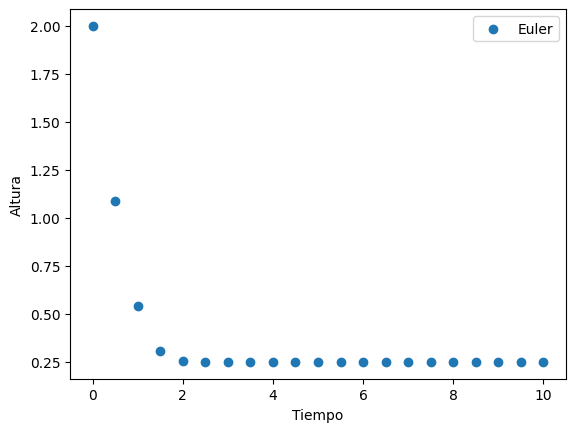

In [ ]:
# A = área transversal del tanque
# h = altura de la columna de agua
# qi = caudal de entrada del líquido
# qo = caudal de salida del líquido
# R = resistencia de salida

def euler(A, qi, h0, R, t0, tf, h):

    def qo(altura):
        return (1 / R) * np.sqrt(max(altura, 0))
    
    def f(t, altura):
        return 1/A * (qi - qo(altura))
    
    t_valores = [t0]
    h_valores = [h0]

    t_actual = t0
    h_actual = h0

    while t_actual < tf:
        h_actual = h_actual + f(t_actual, h_actual) * h
        t_actual = t_actual + h

        t_valores.append(t_actual)
        h_valores.append(h_actual)

    return np.array(t_valores), np.array(h_valores), qo()

# Parámetros

A = 1
R = 0.5
qi = 1
h0 = 2 
t0 = 0
tf = 10



t_euler, h_euler = euler(A, qi, h0, R, t0, tf, 0.5)

plt.scatter(t_euler, h_euler, label='Euler')
plt.xlabel('Tiempo')
plt.ylabel('Altura')
plt.title('Altura del líquido en el tanque con un caudal de salida: ')

plt.legend()
plt.show()

**(b)** Analizar cómo cambian el nivel de líquido y el caudal de salida para $R: 0.25,\ 0.5,\ 0.95$. ¿Qué función cumple $R$?

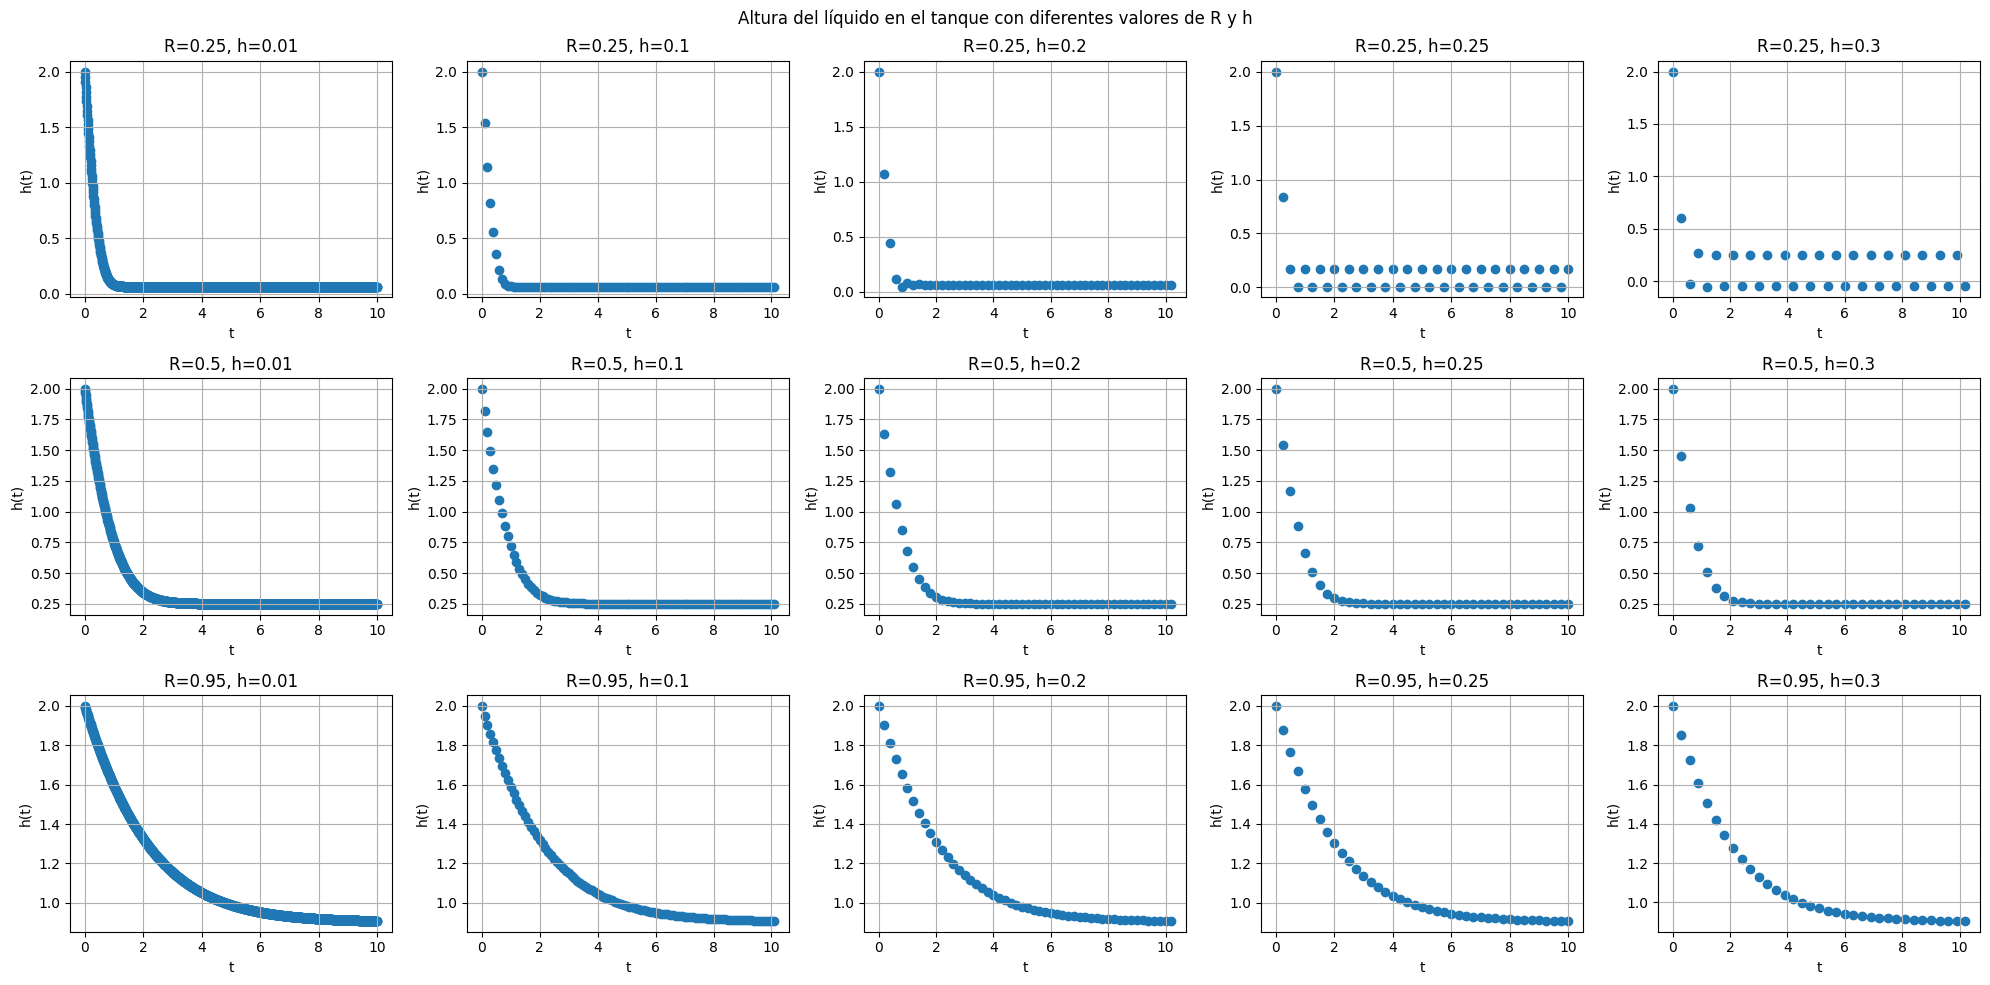

In [14]:
R_vals = [0.25, 0.5, 0.95]
h_vals = [0.01, 0.1, 0.2, 0.25, 0.3]

# Gráfico

fig, axes = plt.subplots(len(R_vals), len(h_vals), figsize=(20, 10))

for i, R in enumerate(R_vals):
    for j, h in enumerate(h_vals):
        ax = axes[i, j]

        tiempos, alturas = euler(A, qi, h0, R, t0, tf, h)

        ax.scatter(tiempos, alturas)
        ax.grid(True)
        ax.set_xlabel('t')
        ax.set_ylabel('h(t)')
        ax.set_title(f'R={R}, h={h}')
        
fig.suptitle('Altura del líquido en el tanque con diferentes valores de R y h')
plt.tight_layout()
plt.show()